In [3]:
import tensorflow as tf
from tensorflow import keras

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

In [4]:
# ==========================================================
# Cell 2: Data Ingestion & Shape Verification
# ==========================================================

# Load the MNIST dataset
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.mnist.load_data()

# Verify dataset shapes
print("Training Images Shape :", X_train_raw.shape)
print("Training Labels Shape :", y_train_raw.shape)

print("Test Images Shape     :", X_test_raw.shape)
print("Test Labels Shape     :", y_test_raw.shape)

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Test Images Shape     : (10000, 28, 28)
Test Labels Shape     : (10000,)


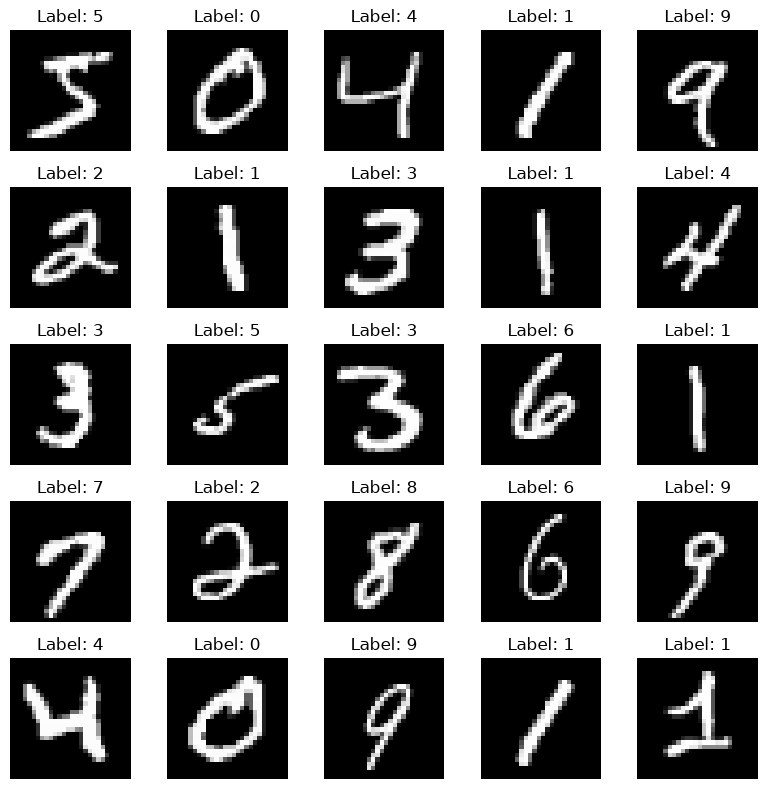

label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


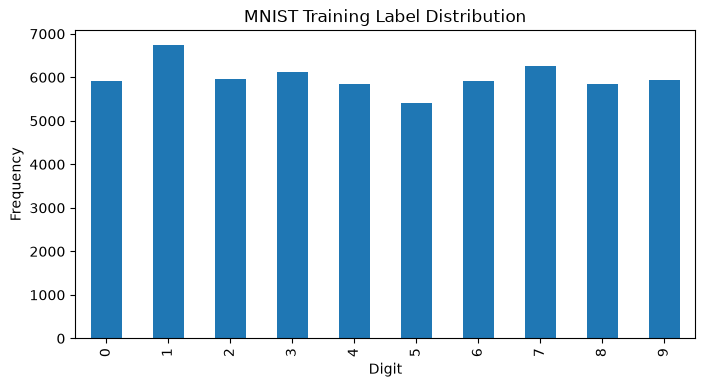

In [7]:
# ==========================================================
# Cell 3: Exploratory Data Analysis & Visual Inspection
# ==========================================================

plt.figure(figsize=(8, 8))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_raw[i], cmap="gray")
    plt.title(f"Label: {y_train_raw[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

labels_df = pd.DataFrame({
    "label": y_train_raw
})

class_counts = labels_df["label"].value_counts().sort_index()

print(class_counts)

plt.figure(figsize=(8,4))
class_counts.plot(kind="bar")

plt.title("MNIST Training Label Distribution")
plt.xlabel("Digit")
plt.ylabel("Frequency")

plt.show()

In [12]:
#=================================================================
# Cell 4: Preprocessing Pipeline & Data preparartion/normalisation

# Flatten images into 1D feature vectors
X_train = X_train_raw.reshape(-1, 784)
X_test = X_test_raw.reshape(-1, 784)

# Convert to float32 and normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

y_train = y_train_raw
y_test = y_test_raw
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Training dtype:", X_train.dtype)

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Training shape: (60000, 784)
Test shape: (10000, 784)
Training dtype: float32
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [13]:
# ==========================================================
# Cell 5: Feed-Forward Neural Network Architecture
# ==========================================================

model = keras.Sequential([
    
    keras.layers.Input(shape=(784,)),

    keras.layers.Dense(128, activation="relu"),

    keras.layers.Dense(10, activation="softmax")
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# ==========================================================
# Cell 6: Model Compilation
# ==========================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
# ==========================================================
# Cell 7: Model Training
# ==========================================================

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9085 - loss: 0.3316 - val_accuracy: 0.9502 - val_loss: 0.1771
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.9556 - loss: 0.1532 - val_accuracy: 0.9622 - val_loss: 0.1322
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9692 - loss: 0.1085 - val_accuracy: 0.9657 - val_loss: 0.1149
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9767 - loss: 0.0822 - val_accuracy: 0.9674 - val_loss: 0.1054
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9826 - loss: 0.0642 - val_accuracy: 0.9699 - val_loss: 0.0987
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9867 - loss: 0.0508 - val_accuracy: 0.9722 - val_loss: 0.0935
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9902 - loss: 0.0404 - val_accuracy: 0.9728 - val_loss: 0.0906
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9926 - loss: 0.0320 - 

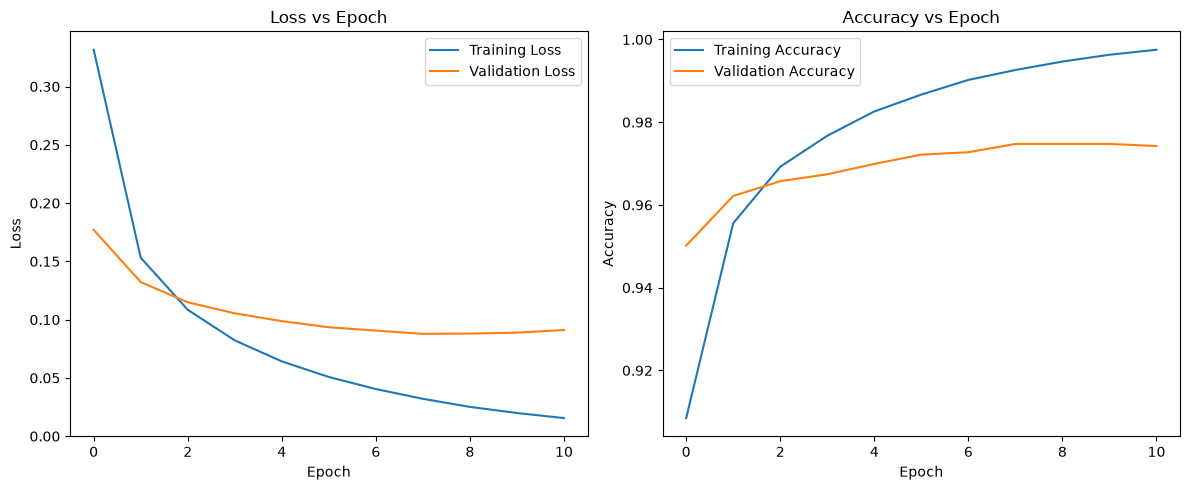

In [16]:
# ==========================================================
# Cell 8: Learning Curves Evaluation
# ==========================================================

metrics_df = pd.DataFrame(history.history)

metrics_df

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(metrics_df["loss"], label="Training Loss")
plt.plot(metrics_df["val_loss"], label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(metrics_df["accuracy"], label="Training Accuracy")
plt.plot(metrics_df["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9743 - loss: 0.0805

Test Loss: 0.0805
Test Accuracy: 0.9743
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Number of misclassified images: 257


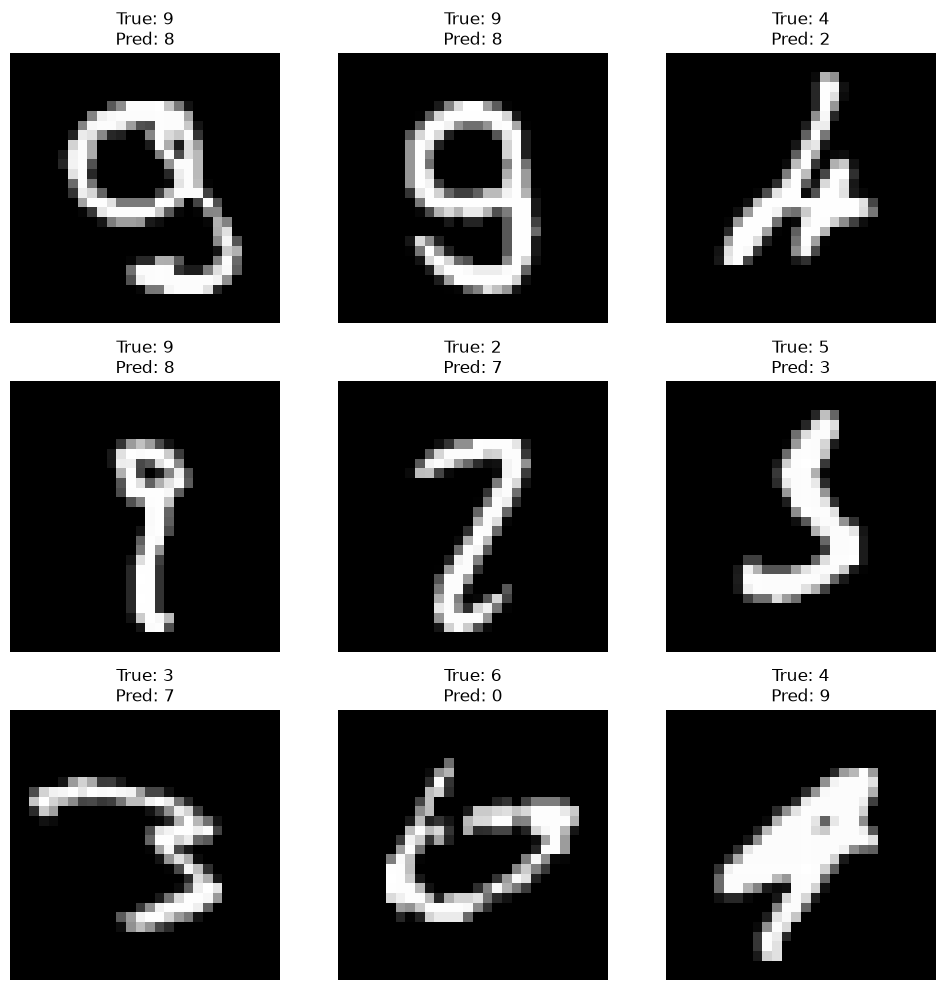

In [18]:
# ==========================================================
# Cell 9: Test Set Evaluation
# ==========================================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)
misclassified = np.where(predicted_labels != y_test)[0]

print(f"Number of misclassified images: {len(misclassified)}")

plt.figure(figsize=(10, 10))

for i in range(9):
    idx = misclassified[i]

    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test_raw[idx], cmap="gray")

    plt.title(
        f"True: {y_test[idx]}\nPred: {predicted_labels[idx]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

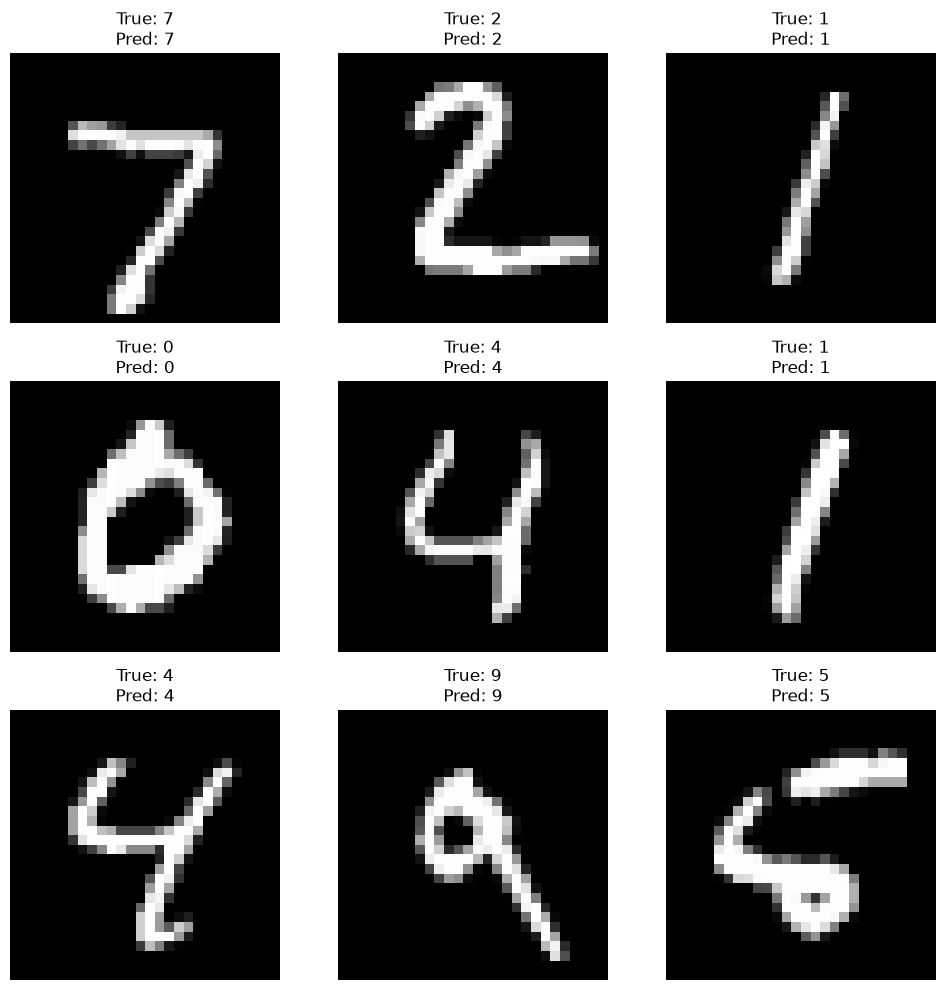

In [19]:
# ==========================================================
# Display Correctly Classified Images
# ==========================================================

correct = np.where(predicted_labels == y_test)[0]

plt.figure(figsize=(10, 10))

for i in range(9):
    idx = correct[i]

    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test_raw[idx], cmap="gray")

    plt.title(
        f"True: {y_test[idx]}\nPred: {predicted_labels[idx]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
# ==========================================================
# Cell 10: Save the Trained Model
# ==========================================================

model.save("mnist_ffnn.keras")

print("Model saved successfully!")

Model saved successfully!
